# What's Really Inside the S&P 500?
## Phase 2: Sector Analysis

**Central Question:** What's really inside the S&P 500? Analyzing the composition, concentration, and turnover of the world's most popular index to understand what investors are actually buying.

---

### Overview

When buying an S&P 500 index fund, you're not buying 500 equal slices of the economy. Some sectors are massive and they dominate that indes and drive its returns. Others are tiny. Understanding the breakdown is crucial to understanding what you're invested in.

This notebook examines the S&P 500 from three angles: 

1. **Sector composition by company count** — how many companies belong to each sector
2. **Sector composition by market cap weight** — how much of the index each sector actually controls
3. **Sector performance over time** — which sectors have driven or dragged on the index over the past 10 years

---
## Step 1: Libraries & Data

Libraries used:

- **pandas** — data manipulation and analysis
- **matplotlib** — data visualization

Dataset used:
- **Company list** - has every company's ticker, name, sector, and sub-industry
- **Market cap data** - similar and inculdes each company's market capitalization

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
companies = pd.read_csv('data/sp500_companies.csv')
market_cap = pd.read_csv('data/sp500_companies_market_cap.csv')

### 1A: Data check

Confirming row counts, column names, and checking for missing market cap values before starting the analysis.

In [11]:
companies.head()

,ticker,company,sector,sub_industry,headquarters,date_added,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1989


In [12]:
market_cap.head()

,ticker,company,sector,sub_industry,headquarters,date_added,founded,market_cap,market_cap_billions
0,NVDA,Nvidia,Information Technology,Semiconductors,"Santa Clara, California",2001-11-30,1993,4161988460544,4161.988461
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals","Cupertino, California",1982-11-30,1977,3716958388224,3716.958388
2,GOOGL,Alphabet Inc. (Class A),Communication Services,Interactive Media & Services,"Mountain View, California",2006-04-03,1998,3398289588224,3398.289588
3,GOOG,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,"Mountain View, California",2014-04-03,1998,3396111695872,3396.111696
4,MSFT,Microsoft,Information Technology,Systems Software,"Redmond, Washington",1994-06-01,1975,2720027377664,2720.027378


---
## Step 2: Sector Composition by Company Count

The simplest view of sector composition: how many companies belong to each sector?

This won't tell us how *important* each sector is (a sector could have lots of small companies), but it's a starting point and it sets up a useful comparison with the market-cap-weighted view we'll do next.

In [19]:
sector_counts = companies['sector'].value_counts()
sector_counts

sector
Industrials               79
Financials                76
Information Technology    73
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64

### 2A: Company count visual

Horizontal bar chart of company count per sector, sorted largest to smallest.

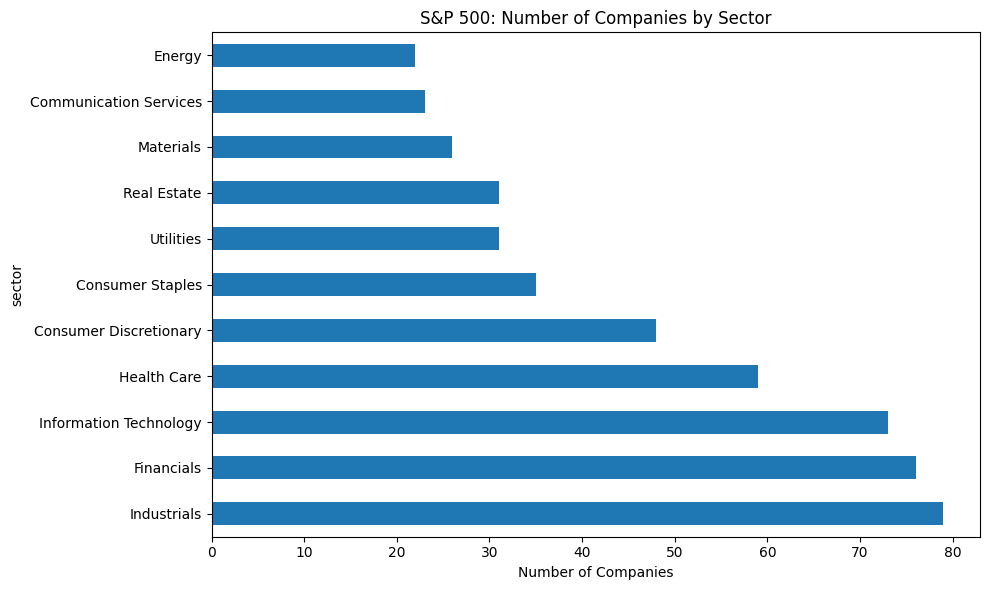

In [23]:
sector_counts.plot(kind='barh', figsize=(10,6))
plt.title('S&P 500: Number of Companies by Sector')
plt.xlabel('Number of Companies')
plt.tight_layout()
plt.show()

---
## Step 3: Sector Composition by Market Cap Weight

The S&P 500 is a **market-cap-weighted** index, meaning bigger companies have more influence. A sector with 30 companies that are all mega-caps will dominate the index far more than a sector with 70 smaller companies.

Using `.groupby()` to sum market cap by sector, then converting to percentage weights.

In [29]:
sector_market_cap = market_cap.groupby('sector')['market_cap'].sum()
sector_market_cap

sector
Communication Services     9890221590528
Consumer Discretionary     6210260282368
Consumer Staples           3454535728640
Energy                     2320071032832
Financials                 7711303286272
Health Care                5449844251136
Industrials                5185246469120
Information Technology    18657282482176
Materials                  1165957209088
Real Estate                1105139935232
Utilities                  1431848017920
Name: market_cap, dtype: int64

### 3A: Percentage weights

Converting raw market cap totals to percentage weights.


In [30]:
sector_weight = (sector_market_cap / sector_market_cap.sum()) * 100
sector_weight = sector_weight.sort_values(ascending=False).round(2)
sector_weight

sector
Information Technology    29.81
Communication Services    15.80
Financials                12.32
Consumer Discretionary     9.92
Health Care                8.71
Industrials                8.29
Consumer Staples           5.52
Energy                     3.71
Utilities                  2.29
Materials                  1.86
Real Estate                1.77
Name: market_cap, dtype: float64

### 3B: Market cap weight visual

Horizontal bar chart of sector weights.

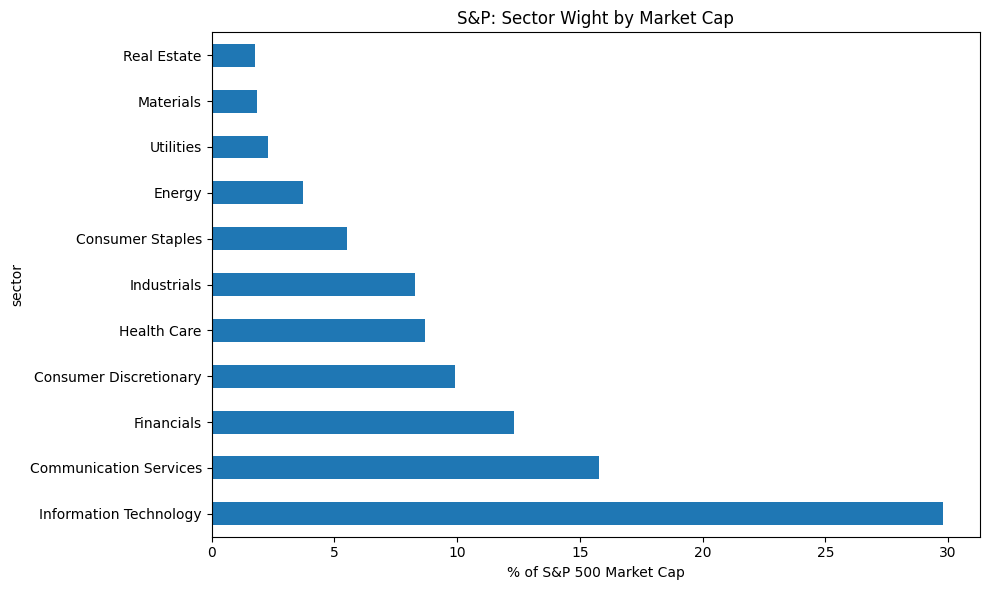

In [ ]:
sector_weight.plot(kind='barh', figsize=(10,6))
plt.title('S&P: Sector Weight by Market Cap')
plt.xlabel('% of S&P 500 Market Cap')
plt.tight_layout()
plt.show()

---
## Step 4: Side-by-Side Comparison - Count vs. Weight

Putting both views together: company count percentage on the left, market cap weight on the right. If a sector has 10% of the companies but 30% of the market cap, that tells you something important about the concentration.

Both metrics are converted to percentages for consistency.

In [33]:
#Converting company counts to %
count_pct = (sector_counts / sector_counts.sum()) * 100

#Combining to one dataframe
compare = pd.DataFrame({
  'Company Count %': count_pct,
  'Market Cap Weight %': sector_weight
})

compare = compare.sort_values('Market Cap Weight %', ascending=False)
compare

,Company Count %,Market Cap Weight %
sector,,
Information Technology,14.512922,29.81
Communication Services,4.572565,15.80
Financials,15.109344,12.32
Consumer Discretionary,9.542744,9.92
Health Care,11.729622,8.71
Industrials,15.705765,8.29
Consumer Staples,6.958250,5.52
Energy,4.373757,3.71
Utilities,6.163022,2.29


### 4A: Side-by-Side visual

Two-panel bar chart comparing % of companies vs. % of market cap for each sector, sorted by market cap weight.

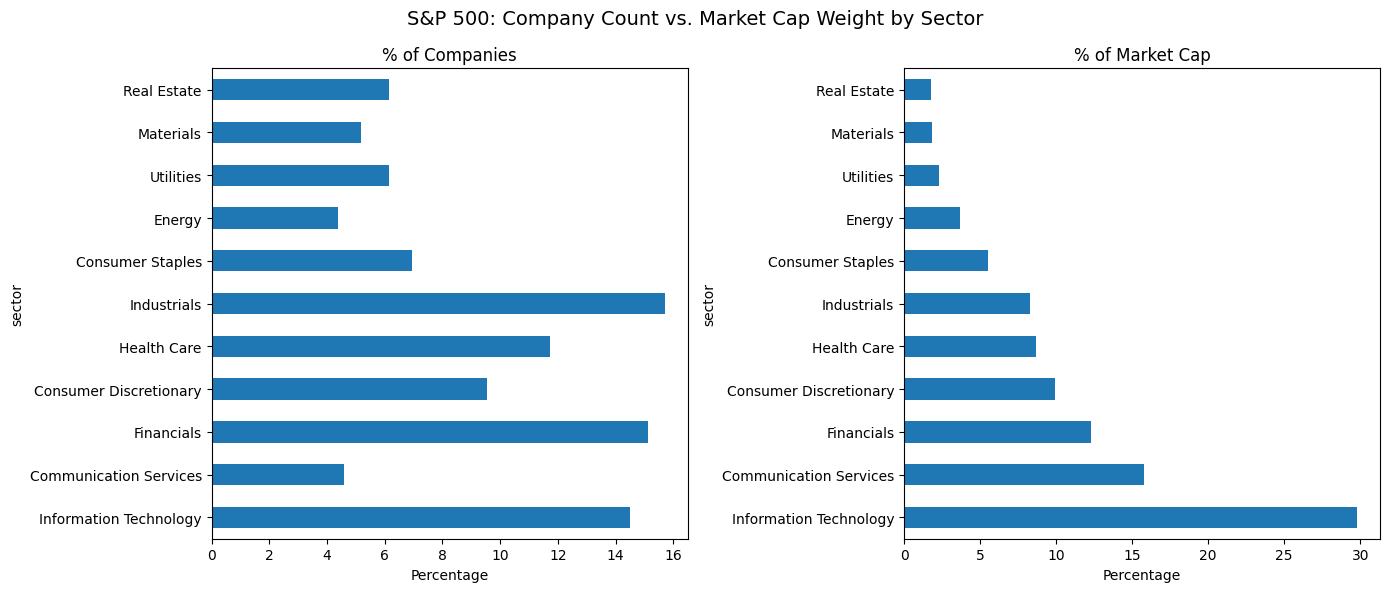

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

compare['Company Count %'].plot(kind='barh', ax=ax1)
ax1.set_title('% of Companies')
ax1.set_xlabel('Percentage')

compare['Market Cap Weight %'].plot(kind='barh', ax=ax2)
ax2.set_title('% of Market Cap')
ax2.set_xlabel('Percentage')

fig.suptitle('S&P 500: Company Count vs. Market Cap Weight by Sector', fontsize=14)
plt.tight_layout()
plt.show()


---
## Step 5: Sector Performance Over Time

The focus here changes from composition to performance.

For reference:

| ETF | Sector |
|-----|--------|
| XLK | Technology |
| XLV | Health Care |
| XLF | Financials |
| XLY | Consumer Discretionary |
| XLP | Consumer Staples |
| XLE | Energy |
| XLI | Industrials |
| XLB | Materials |
| XLRE | Real Estate |
| XLU | Utilities |
| XLC | Communication Services |

Loading the sector ETF price data collected in Phase 1.

In [43]:
sector_etfs = pd.read_csv('data/sector_etf_history.csv', index_col='Date', parse_dates=True)
sector_etfs.head()

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2016-03-28,18.297419,NaN,20.501545,15.080604,46.413338,19.536129,40.480343,22.469252,17.848343,57.098042,35.119564
2016-03-29,18.399668,NaN,20.598202,15.107557,46.716358,19.841444,40.780491,22.956009,18.112061,57.760784,35.475719
2016-03-30,18.481459,NaN,20.638197,15.195153,46.800541,19.958189,41.049839,22.905897,18.068106,57.769279,35.701145
2016-03-31,18.326046,NaN,20.628201,15.161465,46.691101,19.917782,40.834358,23.020433,18.174326,57.590855,35.660553
2016-04-01,18.501907,NaN,20.351562,15.296237,46.909966,20.070438,41.265335,23.068392,18.243912,58.245113,35.809341


### 5A: Normalizing prices to a common starting point

This has to take place because each ETF has a different price, so I can't compare them directly. For example, a $200 ETF that goes to $210 is a 5% gain, same as a $50 ETF going to $52.50. To compare them fairly, I have to **normalize** by dividing every price by the first price in the series, then multiply by 100.

This will convert everything to a ***"started at 100"*** scale. Now if a normalized value is 125, that sector is up 25% from the start. If it's 75, it's down 25%.

**Note:** XLC (Communication Services) was created in 2018, so it has NaN values for earlier dates. The starting date for this sector will be when the data begins.

In [45]:
normalized = (sector_etfs / sector_etfs.apply(lambda x: x.dropna().iloc[0]) * 100)
normalized.head().round(2)

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2016-03-28,100.00,NaN,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2016-03-29,100.56,NaN,100.47,100.18,100.65,101.56,100.74,102.17,101.48,101.16,101.01
2016-03-30,101.01,NaN,100.67,100.76,100.83,102.16,101.41,101.94,101.23,101.18,101.66
2016-03-31,100.16,NaN,100.62,100.54,100.60,101.95,100.87,102.45,101.83,100.86,101.54
2016-04-01,101.12,NaN,99.27,101.43,101.07,102.73,101.94,102.67,102.22,102.01,101.96


### 5B: Sector performance over 10 years visual

All 11 sector ETFs plotted on a single line chart with a reference line at 100 (the starting point).

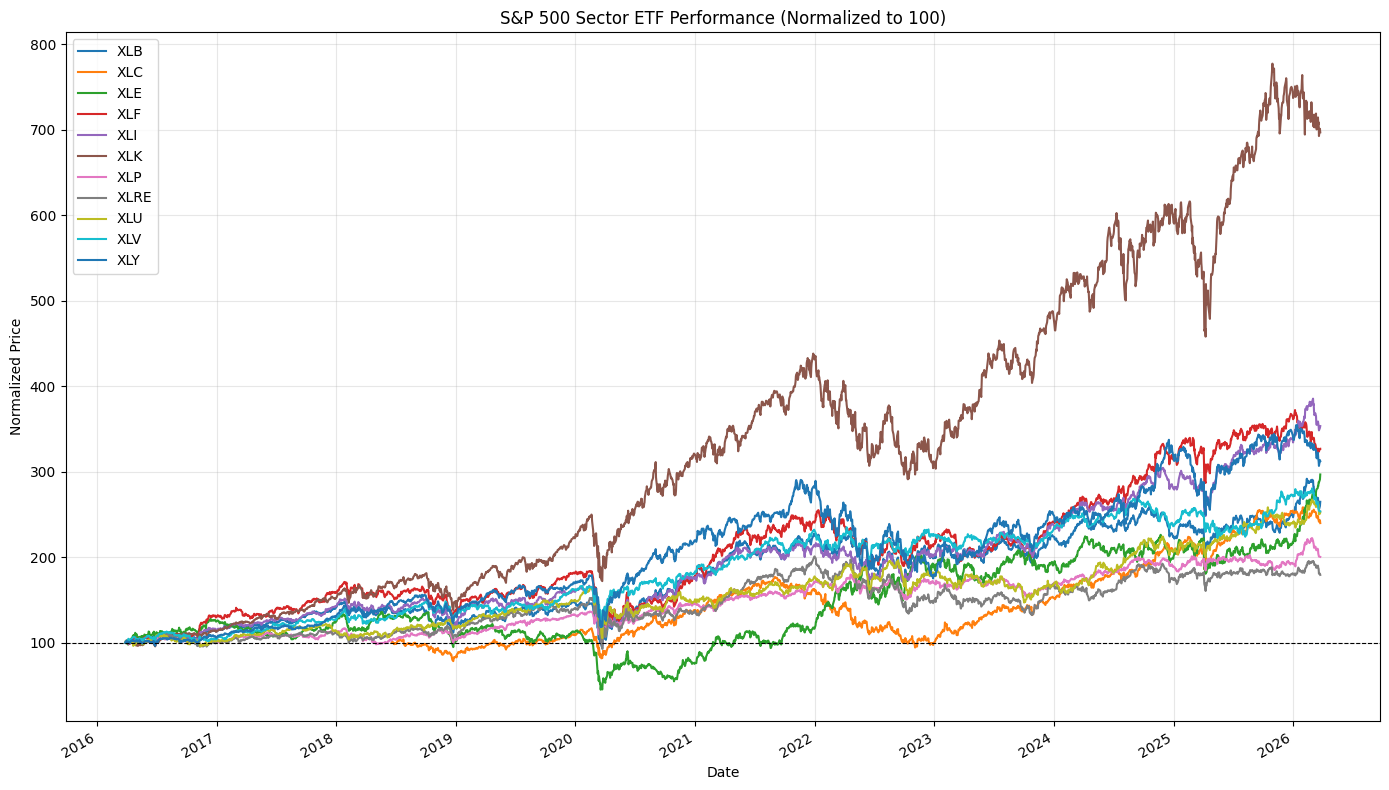

In [47]:
normalized.plot(figsize=(14,8))
plt.title('S&P 500 Sector ETF Performance (Normalized to 100)')
plt.ylabel('Normalized Price')
plt.axhline(y=100, color='black', linestyle='--', linewidth=0.8)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6: Sector Returns Summary

This is the total return for each sector ETF over the full 10 years period. The percentage change represents the difference from the first available price to the last price.

In [54]:
total_returns = ((sector_etfs.iloc[-1] / sector_etfs.apply(lambda x: x.dropna().iloc[0])) -1) * 100
total_returns = total_returns.sort_values(ascending=False).round(2)
print('In percentage')
total_returns

In percentage


XLK     596.91
XLI     253.35
XLF     226.78
XLY     212.30
XLE     196.76
XLB     164.79
XLV     153.58
XLU     152.63
XLC     139.90
XLP     100.37
XLRE     79.31
dtype: float64

### 6A: Total returns visual

Horizontal bar chart ranking all sectors by total return over the full period.

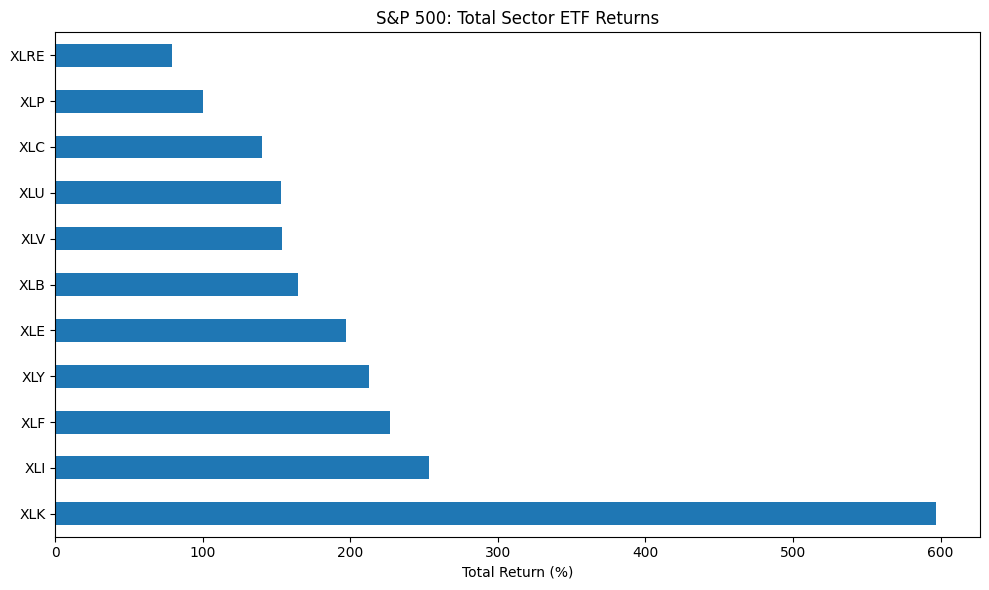

In [53]:
total_returns.plot(kind='barh', figsize=(10, 6))
plt.title('S&P 500: Total Sector ETF Returns')
plt.xlabel('Total Return (%)')
plt.tight_layout()
plt.show()

---
## Key Takeaways

After this sector analysis, here are a few observations

  - The Industrials sector leads the S&P 500 in company count with 79 companies, but the Information Technology sector holds the highest market cap weight at nearly 30%. The two sectors have a similar number of companies (79 vs. 73), yet Tech carries more than three times the weight. What I find interesting is that Industrials doesn't even crack the top 5 for market cap weight.

  - Some sectors punch well above their weight. Communication Services only makes up 4.6% of companies but controls 15.8% of the index's market cap — that's mostly Alphabet and Meta carrying the load. On the flip side, Industrials has 15.7% of the companies but only 8.3% of the weight. More companies doesn't mean more influence.

  - Over the past 10 years, the Information Technology sector absolutely outperformed the other sectors by over 300%, with an almost 600% return. On the other hand, the Real Estate sector performed the worst with only a 79.31% return. The difference between the best and the worst sector, in terms of return, is a staggering 517.6%.

  - This analysis makes me question if us as investors, are we really diversifying when we place funds in the S&P 500 index. Tech alone is nearly 30% of the index, and when you add Communication Services, that's close to 46% in tech-related sectors. That's not a diversified bet across the economy, it's a tech-heavy index dressed up as one.